# 천안 유령버스 — 데이터 분석 및 소멸(유령버스) 집계
국토교통부 TAGO 버스도착정보 API(30초 로깅, 2026년 7월 평일 10일·3개 정류장)로 '곧 도착' 정보가 갱신 없이 사라지는 현상을 정의·집계·시각화한다.

**목차** — 1. 데이터 로드 2. 전처리 3. 유령버스 정의 4. 집계 5. 시각화 6. 결론

In [1]:
#@title 데이터 준비 (실행만 하세요)
import base64, os
os.makedirs('data', exist_ok=True)
_CSV = {
    "bus_log_2026-07-06.csv": "...",
    "bus_log_2026-07-07.csv": "...",
    "bus_log_2026-07-08.csv": "...",
    "bus_log_2026-07-09.csv": "...",
    "bus_log_2026-07-10.csv": "...",
    "bus_log_2026-07-13.csv": "...",
    "bus_log_2026-07-14.csv": "...",
    "bus_log_2026-07-15.csv": "...",
    "bus_log_2026-07-16.csv": "...",
    "bus_log_2026-07-17.csv": "...",
}
for _n, _b in _CSV.items():
    open(os.path.join('data', _n), 'wb').write(base64.b64decode(_b))


In [2]:
try:
    import koreanize_matplotlib
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "koreanize-matplotlib"])
    import koreanize_matplotlib
import matplotlib.pyplot as plt
NAVY, BLUE, RED, GREEN, GREY, ORANGE = "#1a2b4a", "#2e86de", "#c0392b", "#27ae60", "#b8c4d6", "#e69500"

In [3]:
import csv, glob, statistics
import numpy as np, pandas as pd
from datetime import datetime
from collections import defaultdict

DATA_DIR = "data"
SPEC_DAYS = ["2026-07-06","2026-07-08","2026-07-09","2026-07-14","2026-07-17",
             "2026-07-07","2026-07-10","2026-07-13","2026-07-15","2026-07-16"]

## 1. 데이터 로드

In [4]:
def load(path):
    rows = []
    with open(path, encoding="utf-8-sig") as fh:
        for r in csv.DictReader(fh):
            try:
                t = datetime.strptime(r["수집시각"], "%Y-%m-%d %H:%M:%S")
            except ValueError:
                continue
            rows.append((t, r["정류장"], r["노선번호"], int(r["남은정거장"]), int(r["도착예정초"])))
    return rows

data = {}
for p in glob.glob(f"{DATA_DIR}/*.csv"):
    rows = load(p)
    if rows:
        data[rows[0][0].strftime("%Y-%m-%d")] = rows
print("불러온 날짜:", len(data), "일")

불러온 날짜: 10 일


## 2. 전처리 — 10일 통합, 날짜·시간대 부여

In [5]:
frames = []
for p in glob.glob(f"{DATA_DIR}/*.csv"):
    df = pd.read_csv(p, encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    df["날짜"] = pd.to_datetime(df["수집시각"]).dt.strftime("%Y-%m-%d")
    if df["날짜"].iloc[0] not in SPEC_DAYS:
        continue
    df["시간대"] = np.where(pd.to_datetime(df["수집시각"]).dt.hour < 15, "낮", "오후")
    frames.append(df)
raw = pd.concat(frames, ignore_index=True)
print("통합 로그:", f"{len(raw):,}행")
raw[["날짜","시간대","수집시각","정류장","노선번호","남은정거장","도착예정초"]].head()

통합 로그: 23,710행


,날짜,시간대,수집시각,정류장,노선번호,남은정거장,도착예정초
0,2026-07-10,오후,2026-07-10 15:59:53,종합터미널,13,18,2334
1,2026-07-10,오후,2026-07-10 15:59:53,종합터미널,13,10,1120
2,2026-07-10,오후,2026-07-10 15:59:53,종합터미널,14,12,1501
3,2026-07-10,오후,2026-07-10 15:59:53,종합터미널,14,3,488
4,2026-07-10,오후,2026-07-10 15:59:53,종합터미널,20,5,644


## 3. 유령버스(소멸) 정의
곧도착(남은정거장 ≤ 2, 도착예정초 ≤ 180)으로 연속 표시되던 노선이 ① 다음 스냅샷에서 사라지고 ② 사라지기 직전 예정초 > 스냅샷간격+20초 ③ 세션 끝까지 재등장 없음 ④ 세션 종료 3분 이내 제외 — 4조건을 모두 충족하면 소멸(유령).

In [6]:
def episodes(day):
    rows = data[day]
    snaps = sorted(set(x[0] for x in rows))
    interval = statistics.median([(snaps[i+1]-snaps[i]).total_seconds() for i in range(len(snaps)-1)])
    sess_end = snaps[-1]
    sm = {s: defaultdict(list) for s in snaps}
    for t, st, rt, rem, eta in rows:
        sm[t][(st, rt)].append((rem, eta))
    nf = {}
    for i, s in enumerate(snaps):
        for (st, rt), buses in sm[s].items():
            near = [(rem, eta) for rem, eta in buses if rem <= 2 and eta <= 180]
            if near:
                nf[(i, st, rt)] = min(near, key=lambda x: x[1])
    out = []
    for (st, rt) in set((k[1], k[2]) for k in nf):
        idx = sorted(i for (i, a, b) in nf if a == st and b == rt)
        runs, cur = [], [idx[0]]
        for j in idx[1:]:
            if j == cur[-1] + 1:
                cur.append(j)
            else:
                runs.append(cur); cur = [j]
        runs.append(cur)
        for run in runs:
            i0, i1 = run[0], run[-1]
            eta_last = nf[(i1, st, rt)][1]
            ended = (i1 + 1, st, rt) not in nf
            had_time = eta_last > interval + 20
            reappear = any((j, st, rt) in nf for j in range(i1 + 2, len(snaps)))
            near_end = (sess_end - snaps[i1]).total_seconds() <= 180
            ghost = int(ended and had_time and not reappear and not near_end)
            out.append(dict(날짜=day, 시간대=("낮" if snaps[i0].hour < 15 else "오후"),
                            정류장=st, 노선=rt,
                            표시지속초=int((snaps[i1]-snaps[i0]).total_seconds()), 소멸여부=ghost))
    return out

ep = pd.DataFrame([e for d in SPEC_DAYS if d in data for e in episodes(d)])
N = len(ep); G = int(ep["소멸여부"].sum())
print(f"곧도착 에피소드 {N}건 · 유령(소멸) {G}건 ({G/N*100:.1f}%) · BIS 신뢰도 {100-G/N*100:.1f}%")

곧도착 에피소드 360건 · 유령(소멸) 104건 (28.9%) · BIS 신뢰도 71.1%


## 4. 집계 — 정류장·노선·시간대별 소멸률 (표본수 병기)

In [7]:
def rate(col, minn=1):
    g = ep.groupby(col)["소멸여부"].agg(["mean", "size"]).reset_index()
    g.columns = [col, "소멸률", "표본수"]
    g["소멸률"] = (g["소멸률"] * 100).round(1)
    return g[g["표본수"] >= minn].sort_values("소멸률", ascending=False).reset_index(drop=True)

display(rate("정류장"))
display(rate("노선", 20))
display(rate("시간대"))

,정류장,소멸률,표본수
0,한기대,40.0,25
1,천안역동부광장,38.7,155
2,종합터미널,18.9,180


,노선,소멸률,표본수
0,700,45.0,20
1,11,39.1,23
2,201,35.0,20
3,400,30.0,30
4,200,29.2,24
5,24,20.5,44
6,13,11.1,27


,시간대,소멸률,표본수
0,낮,33.2,187
1,오후,24.3,173


## 5. 시각화
### 5-1. 정류장별 소멸률

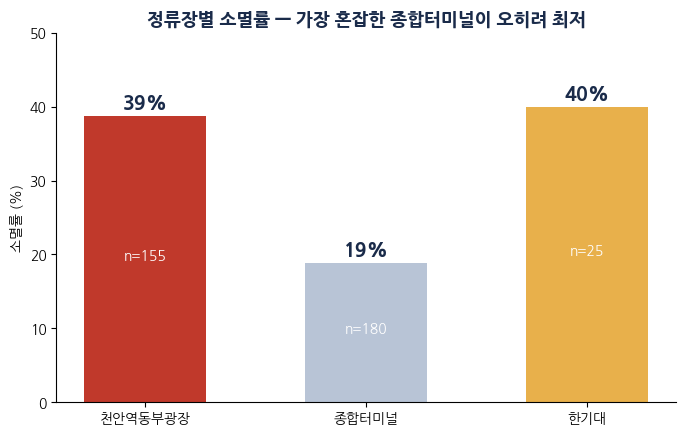

In [8]:
st_r = rate("정류장").set_index("정류장").reindex(["천안역동부광장", "종합터미널", "한기대"])
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(st_r.index, st_r["소멸률"], color=[RED, GREY, "#e8b04b"], width=0.55)
for i, (v, n) in enumerate(zip(st_r["소멸률"], st_r["표본수"])):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=14, fontweight="bold", color=NAVY)
    ax.text(i, v / 2, f"n={n}", ha="center", color="white", fontsize=10)
ax.set_ylabel("소멸률 (%)"); ax.set_ylim(0, 50)
ax.set_title("정류장별 소멸률 — 가장 혼잡한 종합터미널이 오히려 최저", fontsize=13, color=NAVY, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### 5-2. BIS 신뢰도 지수

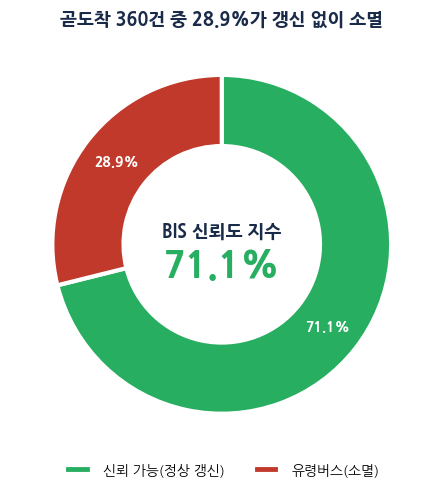

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pie([100 - G/N*100, G/N*100], colors=[GREEN, RED], startangle=90, counterclock=False,
       wedgeprops=dict(width=0.42, edgecolor="white", linewidth=3),
       autopct=lambda p: f"{p:.1f}%", pctdistance=0.79,
       textprops=dict(color="white", fontweight="bold"))
ax.text(0, 0.05, "BIS 신뢰도 지수", ha="center", fontsize=13, color=NAVY, fontweight="bold")
ax.text(0, -0.18, f"{100 - G/N*100:.1f}%", ha="center", fontsize=26, color=GREEN, fontweight="bold")
ax.legend(["신뢰 가능(정상 갱신)", "유령버스(소멸)"], loc="lower center",
          bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
ax.set_title("곧도착 360건 중 28.9%가 갱신 없이 소멸", fontsize=13, color=NAVY, fontweight="bold")
plt.show()

### 5-3. 소멸 지속시간 분포

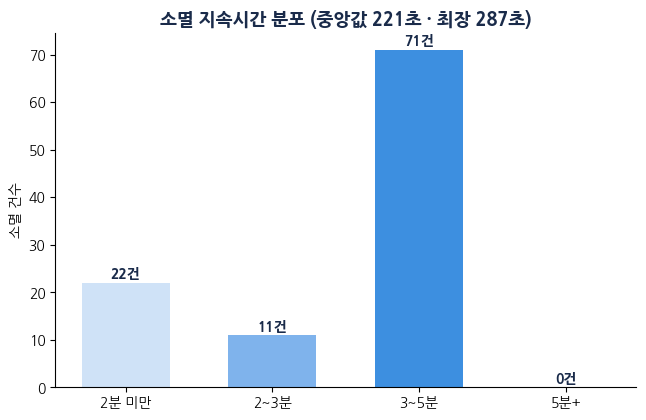

In [10]:
durs = ep.loc[ep["소멸여부"] == 1, "표시지속초"].values
bins = [("2분 미만", (durs < 120).sum()), ("2~3분", ((durs >= 120) & (durs < 180)).sum()),
        ("3~5분", ((durs >= 180) & (durs < 300)).sum()), ("5분+", (durs >= 300).sum())]
fig, ax = plt.subplots(figsize=(7.5, 4.6))
bb = ax.bar([b[0] for b in bins], [int(b[1]) for b in bins],
            color=["#cfe2f7", "#7fb3ec", "#3d8fe0", "#1a6fc4"], width=0.6)
for r, (_, c) in zip(bb, bins):
    ax.text(r.get_x() + r.get_width()/2, c + 1, f"{int(c)}건", ha="center", fontweight="bold", color=NAVY)
ax.set_ylabel("소멸 건수")
ax.set_title(f"소멸 지속시간 분포 (중앙값 {int(np.median(durs))}초 · 최장 {int(durs.max())}초)", fontsize=13, color=NAVY, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### 5-4. 근본 원인 — 도착예정초가 갱신되지 않고 고정

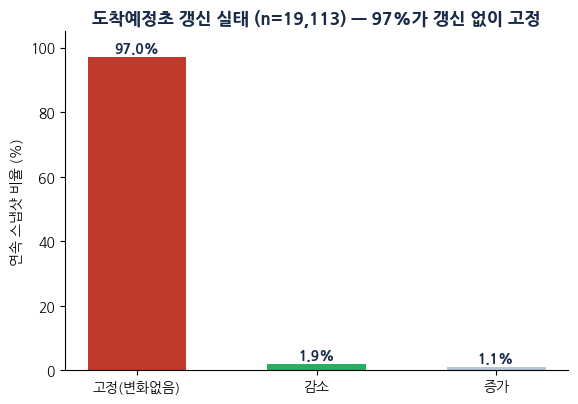

In [11]:
eq = dec = inc = 0
for d in SPEC_DAYS:
    if d not in data:
        continue
    rows = data[d]; snaps = sorted(set(x[0] for x in rows))
    sm = {s: defaultdict(list) for s in snaps}
    for t, st, rt, rem, eta in rows:
        sm[t][(st, rt)].append((rem, eta))
    for i in range(len(snaps) - 1):
        for key, buses in sm[snaps[i]].items():
            nxt = sm[snaps[i+1]].get(key, [])
            for rem, eta in buses:
                cand = [e2 for r2, e2 in nxt if r2 == rem]
                if not cand:
                    continue
                e2 = min(cand, key=lambda e: abs(e - eta))
                if e2 == eta: eq += 1
                elif e2 < eta: dec += 1
                else: inc += 1
tot = eq + dec + inc
fig, ax = plt.subplots(figsize=(6.5, 4.4))
vals = [eq/tot*100, dec/tot*100, inc/tot*100]
bb = ax.bar(["고정(변화없음)", "감소", "증가"], vals, color=[RED, GREEN, GREY], width=0.55)
for r, v in zip(bb, vals):
    ax.text(r.get_x() + r.get_width()/2, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold", color=NAVY)
ax.set_ylabel("연속 스냅샷 비율 (%)"); ax.set_ylim(0, 105)
ax.set_title(f"도착예정초 갱신 실태 (n={tot:,}) — 97%가 갱신 없이 고정", fontsize=12.5, color=NAVY, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 6. 결론
도착예정초의 97%가 갱신 없이 고정 → 유령버스의 근본 원인. 곧도착 정보의 28.9%가 소멸(BIS 신뢰도 71.1%), 소멸의 과반이 천안역에 집중(소멸률 종합터미널의 약 2배). 가장 혼잡한 종합터미널이 오히려 최저 → 혼잡이 아니라 위치추적·정보전송 문제로 추정.

한계: 실제 도착 여부 미확인, 표본 평일 10일·3정류장·낮/오후. 출처: 국토교통부 TAGO API.